<h3> Take the Genre_specific_parquet, standardize all the feature columns except id, then segregate it into Feature_group parquets under folder location -> C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets

In [157]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# ── Column groups ────────────────────────────────────────────────────────────
FEATURE_GROUPS: dict[str, list[str]] = {
    "Timbre": [
        "mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean", "mfcc_4_mean", "mfcc_5_mean", 
        "mfcc_6_mean", "mfcc_7_mean", "mfcc_8_mean", "mfcc_9_mean", "mfcc_10_mean", 
        "mfcc_11_mean", "mfcc_12_mean", "mfcc_13_mean", "mfcc_1_var", "mfcc_2_var", 
        "mfcc_3_var", "mfcc_4_var", "mfcc_5_var", "mfcc_6_var", "mfcc_7_var", "mfcc_8_var",
        "mfcc_9_var", "mfcc_10_var", "mfcc_11_var", "mfcc_12_var", "mfcc_13_var",
        "spectral_centroid_mean", "spectral_centroid_var", "spectral_bandwidth_mean", 
        "spectral_bandwidth_var", "spectral_rolloff_mean", "spectral_rolloff_var", 
        "spectral_contrast_band1_mean", "spectral_contrast_band2_mean",
        "spectral_contrast_band3_mean", "spectral_contrast_band4_mean", 
        "spectral_contrast_band5_mean", "spectral_contrast_band6_mean", 
        "spectral_contrast_band7_mean", "spectral_contrast_band1_var", 
        "spectral_contrast_band2_var", "spectral_contrast_band3_var", 
        "spectral_contrast_band4_var", "spectral_contrast_band5_var", 
        "spectral_contrast_band6_var", "spectral_contrast_band7_var", 
        "zcr_mean", "zcr_var", "rms_mean", "rms_var",
    ],
    "Rhythm": [
        "tempo_bpm", "beat_histogram_bin1", "beat_histogram_bin2", "beat_histogram_bin3",
        "beat_histogram_bin4", "beat_histogram_bin5", "beat_histogram_bin6", 
        "beat_histogram_bin7", "beat_histogram_bin8", "beat_histogram_bin9",
        "beat_histogram_bin10", "ibi_mean", "ibi_var", "ibi_min", "ibi_max", 
        "onset_strength_mean", "onset_strength_var", "onset_strength_max", "onset_strength_median",
    ],
    "Harmony": [
        "chroma_1_mean", "chroma_2_mean", "chroma_3_mean", "chroma_4_mean", "chroma_5_mean",
        "chroma_6_mean", "chroma_7_mean", "chroma_8_mean", "chroma_9_mean", "chroma_10_mean", 
        "chroma_11_mean", "chroma_12_mean", "chroma_1_var", "chroma_2_var", "chroma_3_var", 
        "chroma_4_var", "chroma_5_var", "chroma_6_var", "chroma_7_var", "chroma_8_var", "chroma_9_var", 
        "chroma_10_var", "chroma_11_var", "chroma_12_var", "tonnetz_1_mean", "tonnetz_2_mean", 
        "tonnetz_3_mean", "tonnetz_4_mean", "tonnetz_5_mean", "tonnetz_6_mean", "tonnetz_1_var",
        "tonnetz_2_var", "tonnetz_3_var", "tonnetz_4_var", "tonnetz_5_var", "tonnetz_6_var",
    ],
    "Energy_and_Dynamics": [
        "mel_spec_mean", "mel_spec_var", "mel_spec_max", "mel_spec_min", "mel_spec_median",
    ],
}

def process_audio_features(input_parquet: str, output_folder: str) -> None:
    """
    Read a parquet file, standardise every feature column (all columns except
    'id'), then split the standardised dataframe into characteristic-specific
    parquet files saved in *output_folder*.

    Parameters
    ----------
    input_parquet : str
        Full path to the source parquet file.
    output_folder : str
        Directory where the output parquet files will be written.
        Created automatically if it does not exist.
    """

    # ── 1. Read input ────────────────────────────────────────────────────────
    df = pd.read_parquet(input_parquet)

    if "id" not in df.columns:
        raise ValueError("Input parquet must contain an 'id' column.")

    feature_cols = [c for c in df.columns if c != "id"]

    # ── 2. Standardise feature columns ──────────────────────────────────────
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(df[feature_cols])

    standardised_df = pd.DataFrame(scaled_values, columns=feature_cols, index=df.index)

    # Re-attach 'id' as the first column
    standardised_df.insert(0, "id", df["id"].values)

    print(f"Standardised dataframe shape : {standardised_df.shape}")
    print(f"Columns (first 5)            : {list(standardised_df.columns[:5])} …")

    # ── 3. Split & save characteristic parquets ──────────────────────────────
    os.makedirs(output_folder, exist_ok=True)

    available_cols = set(standardised_df.columns)

    for characteristic, col_list in FEATURE_GROUPS.items():

        # Keep only columns that actually exist in this dataframe
        valid_cols = [c for c in col_list if c in available_cols]

        if not valid_cols:
            print(f"[WARN] No matching columns found for '{characteristic}' — skipping.")
            continue

        # Build subset: id first, then characteristic columns
        subset_df = standardised_df[["id"] + valid_cols].copy()

        out_path = os.path.join(output_folder, f"{characteristic}.parquet")
        subset_df.to_parquet(out_path, index=False)

        print(f"Saved '{characteristic}.parquet'  →  {len(valid_cols)} feature cols, "
              f"{len(subset_df)} rows  [{out_path}]")

    print("\nDone.")

# ── Quick smoke-test (remove / guard behind __main__ in production) ──────────
if __name__ == "__main__":
    # ── Build a tiny synthetic parquet for demonstration ────────────────────
    np.random.seed(42)
    n = 200

    demo_cols = (
        ["id"]
        + FEATURE_GROUPS["Timbre"]
        + FEATURE_GROUPS["Rhythm"]
        + FEATURE_GROUPS["Harmony"]
        + FEATURE_GROUPS["Energy_and_Dynamics"]
    )

    demo_data = {"id": [f"track_{i:04d}" for i in range(n)]}
    for col in demo_cols[1:]:
        demo_data[col] = np.random.randn(n)

    demo_df = pd.DataFrame(demo_data)

    os.makedirs("demo_data", exist_ok=True)
    demo_input = "demo_data/sample_audio_features.parquet"
    demo_df.to_parquet(demo_input, index=False)
    print(f"Demo input written to: {demo_input}\n")

Demo input written to: demo_data/sample_audio_features.parquet



<h4> Function call for -> process_audio_features

In [158]:
    # ── Run the function ─────────────────────────────────────────────────────
    process_audio_features(
        input_parquet=r"C:\SID\Apoorva\Project\Music Maven Project\audio_features_SOUL.parquet",
        output_folder=r"C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL",
    )

Standardised dataframe shape : (1000, 111)
Columns (first 5)            : ['id', 'mfcc_1_mean', 'mfcc_1_var', 'mfcc_2_mean', 'mfcc_2_var'] …
Saved 'Timbre.parquet'  →  50 feature cols, 1000 rows  [C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL\Timbre.parquet]
Saved 'Rhythm.parquet'  →  19 feature cols, 1000 rows  [C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL\Rhythm.parquet]
Saved 'Harmony.parquet'  →  36 feature cols, 1000 rows  [C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL\Harmony.parquet]
Saved 'Energy_and_Dynamics.parquet'  →  5 feature cols, 1000 rows  [C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL\Energy_and_Dynamics.parquet]

Done.


<h4> Verifying the respective parquets

In [159]:
df = pd.read_parquet(r"C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL\Timbre.parquet")
df.head()

,id,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,...,spectral_contrast_band2_var,spectral_contrast_band3_var,spectral_contrast_band4_var,spectral_contrast_band5_var,spectral_contrast_band6_var,spectral_contrast_band7_var,zcr_mean,zcr_var,rms_mean,rms_var
0,0Gj4pqFby71rvq08.mp3,-0.658335,-0.590424,0.800297,0.570006,2.282199,0.803129,2.164138,1.362092,2.417916,...,1.063982,0.613209,1.176352,0.302354,-0.814965,-0.111614,-1.610593,-0.446003,0.674583,1.317888
1,0aTr8HKBZUuxwexW.mp3,-1.093173,0.236900,1.930690,-0.660622,0.712055,-0.901804,1.641325,0.812756,1.601891,...,-0.121296,0.561107,0.234247,-0.140160,1.767743,1.141279,-1.471321,-0.731095,-0.394963,-0.123235
2,0diSaWOZL45lxPZC.mp3,-0.475886,-0.806525,0.533050,2.081838,0.342182,-0.004747,-0.043675,-0.041390,0.741039,...,0.478698,0.827310,1.332303,1.268000,-0.421102,1.291625,-0.670131,0.121635,-0.512577,-0.151589
3,0cQdObcXUyY1tLkj.mp3,-0.459562,1.485853,1.087011,0.242723,0.567327,-0.591580,-0.085473,-0.771988,0.397877,...,-0.809588,-1.066027,-0.851168,-1.073417,-0.979853,-0.707069,-1.068264,-0.869900,-0.292712,-0.516463
4,09zRPbUiTrBZJoi2.mp3,-0.405234,0.609809,0.584806,-0.819788,2.340775,0.529338,-0.021780,-0.441852,0.108286,...,0.527840,1.119836,1.192223,1.038556,-0.325356,-0.332041,-0.931480,0.256788,0.975307,2.729473


In [160]:
df = pd.read_parquet(r"C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL\Harmony.parquet")
df.head()

,id,chroma_1_mean,chroma_2_mean,chroma_3_mean,chroma_4_mean,chroma_5_mean,chroma_6_mean,chroma_7_mean,chroma_8_mean,chroma_9_mean,...,tonnetz_3_mean,tonnetz_4_mean,tonnetz_5_mean,tonnetz_6_mean,tonnetz_1_var,tonnetz_2_var,tonnetz_3_var,tonnetz_4_var,tonnetz_5_var,tonnetz_6_var
0,0Gj4pqFby71rvq08.mp3,0.645404,1.082505,1.932044,1.235509,0.750773,0.436845,0.701822,0.226772,0.432824,...,0.683802,-0.255814,-0.360937,-0.856895,-0.744655,-1.084934,-1.029961,-0.794152,-0.625201,-0.794763
1,0aTr8HKBZUuxwexW.mp3,0.053644,0.212149,1.346528,0.576439,0.225143,1.052843,1.087775,1.778550,0.375005,...,1.637174,1.479512,2.272359,4.000037,0.500355,1.178958,0.016418,1.831526,-0.562718,2.877695
2,0diSaWOZL45lxPZC.mp3,-1.554627,-0.702307,-0.158977,-1.200214,-1.278973,-1.134943,-0.087659,-1.199330,-1.391820,...,0.262779,-1.373988,-1.105388,0.383709,0.767492,2.367569,0.159486,0.441350,0.104224,0.645860
3,0cQdObcXUyY1tLkj.mp3,0.623779,-1.085997,-0.999496,-0.699278,1.558524,0.693886,-0.302063,0.198358,-0.538782,...,-0.533118,1.734662,0.443175,0.026416,-0.533343,0.173321,0.793722,-0.166164,-0.008919,-0.087092
4,09zRPbUiTrBZJoi2.mp3,0.322674,-0.387602,-0.044774,0.950501,-0.735463,-0.897143,-1.229063,-0.604410,1.141859,...,-0.237805,0.182394,-1.385800,-0.218596,0.056831,-0.667382,-0.321730,-0.456948,-0.326630,0.028300


In [161]:
df = pd.read_parquet(r"C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL\Rhythm.parquet")
df.head()

,id,tempo_bpm,beat_histogram_bin1,beat_histogram_bin2,beat_histogram_bin3,beat_histogram_bin4,beat_histogram_bin5,beat_histogram_bin6,beat_histogram_bin7,beat_histogram_bin8,beat_histogram_bin9,beat_histogram_bin10,ibi_mean,ibi_var,ibi_min,ibi_max,onset_strength_mean,onset_strength_var,onset_strength_max,onset_strength_median
0,0Gj4pqFby71rvq08.mp3,-1.249556,-0.472872,-0.614134,-0.709274,-0.615726,2.187997,-1.005463,0.596279,-0.620864,-0.248457,-0.391494,1.355457,-0.913413,1.399805,1.239834,-0.711182,2.844419,1.381102,-2.333941
1,0aTr8HKBZUuxwexW.mp3,0.972913,-0.472872,1.827962,2.429353,-0.836591,0.930922,-0.357292,-0.765533,-0.620864,-0.543360,-0.391494,-0.683600,-0.030697,-0.637757,-0.134400,-1.923596,0.108319,-0.026957,-2.072536
2,0diSaWOZL45lxPZC.mp3,0.186734,-0.472872,-0.189422,-0.709274,1.018671,-0.954692,1.487503,-0.181899,-0.620864,-0.248457,-0.293645,0.008456,-0.307306,-0.055596,0.140447,-0.159137,0.370924,1.211209,0.048315
3,0cQdObcXUyY1tLkj.mp3,-1.249556,-0.245037,-0.083244,0.803993,-0.836591,1.445180,-0.457011,-0.765533,-0.483016,-0.395908,-0.391494,1.473393,0.240691,1.399805,1.789528,-0.556055,-0.494558,-0.738558,-0.396528
4,09zRPbUiTrBZJoi2.mp3,0.186734,-0.472872,-0.401778,0.355618,-0.836591,1.902298,0.440457,-0.765533,0.550837,-0.248457,-0.293645,-0.370818,0.354394,-0.637757,-0.134400,-0.987844,-0.573938,-0.182584,-0.746781


In [162]:
df = pd.read_parquet(r"C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL\Energy_and_Dynamics.parquet")
df.head()

,id,mel_spec_mean,mel_spec_var,mel_spec_max,mel_spec_min,mel_spec_median
0,0Gj4pqFby71rvq08.mp3,-1.995292,1.793259,0.0,-0.048128,-2.256390
1,0aTr8HKBZUuxwexW.mp3,-1.834556,1.725819,0.0,-0.048128,-1.793553
2,0diSaWOZL45lxPZC.mp3,-0.967603,0.295590,0.0,-0.048128,-1.146263
3,0cQdObcXUyY1tLkj.mp3,0.221658,1.006089,0.0,-0.048128,0.332787
4,09zRPbUiTrBZJoi2.mp3,-1.202560,0.979398,0.0,-0.048128,-1.155886


<h4> Applies auto PCA to find optimal components explaining `variance_threshold` of 95%, Saves the reduced dataframe (with 'id' as first column) to output_folder -> genre_specific_feature_isolation_pca_parquets\ELECTRONIC

In [163]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def auto_pca(input_folder: str, output_folder: str,
             variance_threshold: float = 0.95) -> dict:
    """
    For each parquet in input_folder:
      1. Applies auto PCA to find optimal components explaining `variance_threshold` of variance.
      2. Plots explained variance graphs for each parquet.
      3. Displays head of the final dataframe.
      4. Saves the reduced dataframe (with 'id' as first column) to output_folder.

    Args:
        input_folder:        Path to folder containing input .parquet files.
        output_folder:       Path to folder where output .parquet files will be saved.
        variance_threshold:  Cumulative explained variance ratio target for PCA (default 0.95).

    Returns:
        summary dict: {filename: {"n_pca_components": int, "variance_explained": float, "shape_in": tuple, "shape_out": tuple}}
    """

    input_path  = Path(input_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    parquet_files = sorted(input_path.glob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No .parquet files found in: {input_folder}")

    summary = {}

    for pq_file in parquet_files:
        print(f"\n{'='*60}")
        print(f"Processing: {pq_file.name}")
        print(f"{'='*60}")

        # ── 1. Load ───────────────────────────────────────────────
        df = pd.read_parquet(pq_file)
        print(f"  Original shape: {df.shape}")

        # ── 2. Separate id and feature columns ───────────────────
        id_col = "id" if "id" in df.columns else None
        id_series = df[id_col] if id_col else None

        feature_cols = [c for c in df.columns if c != id_col]
        X = df[feature_cols].copy()

        # ── 3. Auto PCA – find optimal n_components ───────────────
        pca_full = PCA().fit(X.values)
        cumvar = np.cumsum(pca_full.explained_variance_ratio_)
        individual_var = pca_full.explained_variance_ratio_

        n_components = int(np.searchsorted(cumvar, variance_threshold) + 1)
        n_components = min(n_components, X.shape[1])  # safety cap

        print(f"  PCA: {n_components} components explain "
              f"{cumvar[n_components-1]*100:.1f}% variance "
              f"(target ≥ {variance_threshold*100:.0f}%)")

        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(X.values)

        pc_cols = [f"PC{i+1}" for i in range(n_components)]
        df_final = pd.DataFrame(X_pca, columns=pc_cols, index=df.index)

        # ── 4. Plot explained variance ────────────────────────────
        _plot_pca_variance(
            pq_file.stem, individual_var, cumvar,
            n_components, variance_threshold, output_path
        )

        # ── 5. Re-attach id as first column ──────────────────────
        if id_series is not None:
            df_final.insert(0, id_col, id_series.values)

        print(f"  Final shape: {df_final.shape}")

        # ── 6. Display head ───────────────────────────────────────
        print(f"\n  Preview of [{pq_file.name}] (head):")
        print(f"  {'-'*50}")
        print(df_final.head().to_string(index=False))
        print(f"  {'-'*50}\n")

        # ── 7. Save to output folder with original filename ───────
        out_file = output_path / pq_file.name
        df_final.to_parquet(out_file, index=False)
        print(f"  Saved → {out_file}")

        summary[pq_file.name] = {
            "n_pca_components":   n_components,
            "variance_explained": float(cumvar[n_components - 1]),
            "shape_in":           df.shape,
            "shape_out":          df_final.shape,
        }

    print(f"\n{'='*60}")
    print(f"Done. {len(parquet_files)} file(s) processed → {output_folder}")
    return summary


def _plot_pca_variance(file_stem: str, individual_var: np.ndarray,
                       cumvar: np.ndarray, n_components: int,
                       variance_threshold: float, output_path: Path):
    """
    Plots 3 charts for a single parquet file:
      - Bar chart: individual explained variance per component
      - Line chart: cumulative explained variance with threshold marker
      - Bar chart: variance of selected components only
    """

    total_components = len(individual_var)
    component_nums   = np.arange(1, total_components + 1)

    fig = plt.figure(figsize=(18, 5))
    fig.suptitle(f"PCA Explained Variance — {file_stem}", fontsize=14, fontweight="bold", y=1.02)
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # ── Plot 1: Individual explained variance (all components) ────
    ax1 = fig.add_subplot(gs[0])
    ax1.bar(component_nums, individual_var * 100,
            color=["steelblue" if i < n_components else "lightgrey"
                   for i in range(total_components)],
            edgecolor="white", linewidth=0.5)
    ax1.axvline(x=n_components + 0.5, color="red", linestyle="--", linewidth=1.5,
                label=f"Cutoff at PC{n_components}")
    ax1.set_xlabel("Principal Component")
    ax1.set_ylabel("Explained Variance (%)")
    ax1.set_title("Individual Explained Variance")
    ax1.legend(fontsize=8)
    ax1.set_xlim(0.5, total_components + 0.5)

    # ── Plot 2: Cumulative explained variance ─────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(component_nums, cumvar * 100, marker="o", markersize=3,
             color="steelblue", linewidth=1.8, label="Cumulative variance")
    ax2.axhline(y=variance_threshold * 100, color="red", linestyle="--",
                linewidth=1.5, label=f"{variance_threshold*100:.0f}% threshold")
    ax2.axvline(x=n_components, color="orange", linestyle="--",
                linewidth=1.5, label=f"PC{n_components} selected")
    ax2.scatter([n_components], [cumvar[n_components - 1] * 100],
                color="orange", zorder=5, s=60)
    ax2.set_xlabel("Number of Components")
    ax2.set_ylabel("Cumulative Explained Variance (%)")
    ax2.set_title("Cumulative Explained Variance")
    ax2.legend(fontsize=8)
    ax2.set_xlim(0.5, total_components + 0.5)
    ax2.set_ylim(0, 105)

    # ── Plot 3: Selected components variance breakdown ─────────────
    ax3 = fig.add_subplot(gs[2])
    selected_var    = individual_var[:n_components] * 100
    selected_labels = [f"PC{i+1}" for i in range(n_components)]
    colors = plt.cm.Blues_r(np.linspace(0.2, 0.7, n_components))
    ax3.bar(selected_labels, selected_var, color=colors, edgecolor="white")
    ax3.set_xlabel("Selected Component")
    ax3.set_ylabel("Explained Variance (%)")
    ax3.set_title(f"Selected {n_components} Components Breakdown")
    if n_components > 10:
        ax3.set_xticks(ax3.get_xticks()[::max(1, n_components // 10)])
    plt.setp(ax3.get_xticklabels(), rotation=45, ha="right", fontsize=7)

    plt.tight_layout()

    # Save plot
    plot_file = output_path / f"{file_stem}_pca_variance.png"
    plt.savefig(plot_file, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Plot saved → {plot_file}")


Processing: Energy_and_Dynamics.parquet
  Original shape: (1000, 6)
  PCA: 3 components explain 99.7% variance (target ≥ 95%)


C:\Users\Sid\AppData\Local\Temp\ipykernel_19788\445239771.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


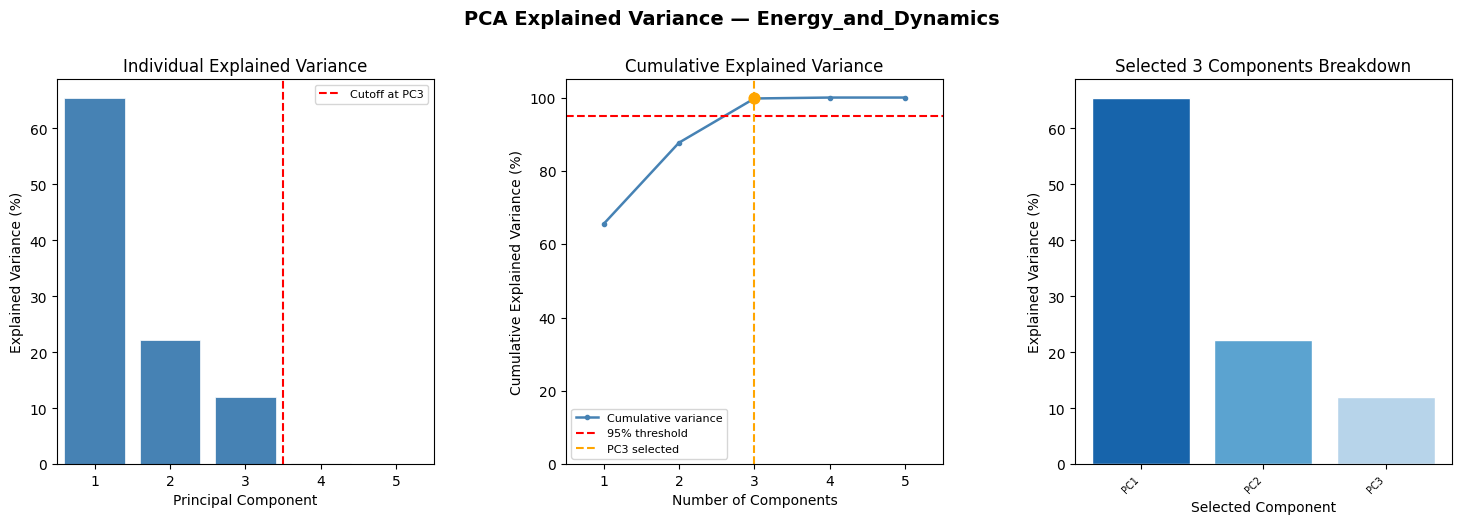

  Plot saved → C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_pca_parquets\SOUL\Energy_and_Dynamics_pca_variance.png
  Final shape: (1000, 4)

  Preview of [Energy_and_Dynamics.parquet] (head):
  --------------------------------------------------
                  id       PC1      PC2       PC3
0Gj4pqFby71rvq08.mp3 -3.370461 0.926992 -0.163526
0aTr8HKBZUuxwexW.mp3 -2.971903 0.854094  0.037385
0diSaWOZL45lxPZC.mp3 -1.402366 0.229121 -0.559126
0cQdObcXUyY1tLkj.mp3 -0.158384 0.263843  1.038844
09zRPbUiTrBZJoi2.mp3 -1.869869 0.489644 -0.085157
  --------------------------------------------------

  Saved → C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_pca_parquets\SOUL\Energy_and_Dynamics.parquet

Processing: Harmony.parquet
  Original shape: (1000, 37)
  PCA: 21 components explain 95.1% variance (target ≥ 95%)


C:\Users\Sid\AppData\Local\Temp\ipykernel_19788\445239771.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


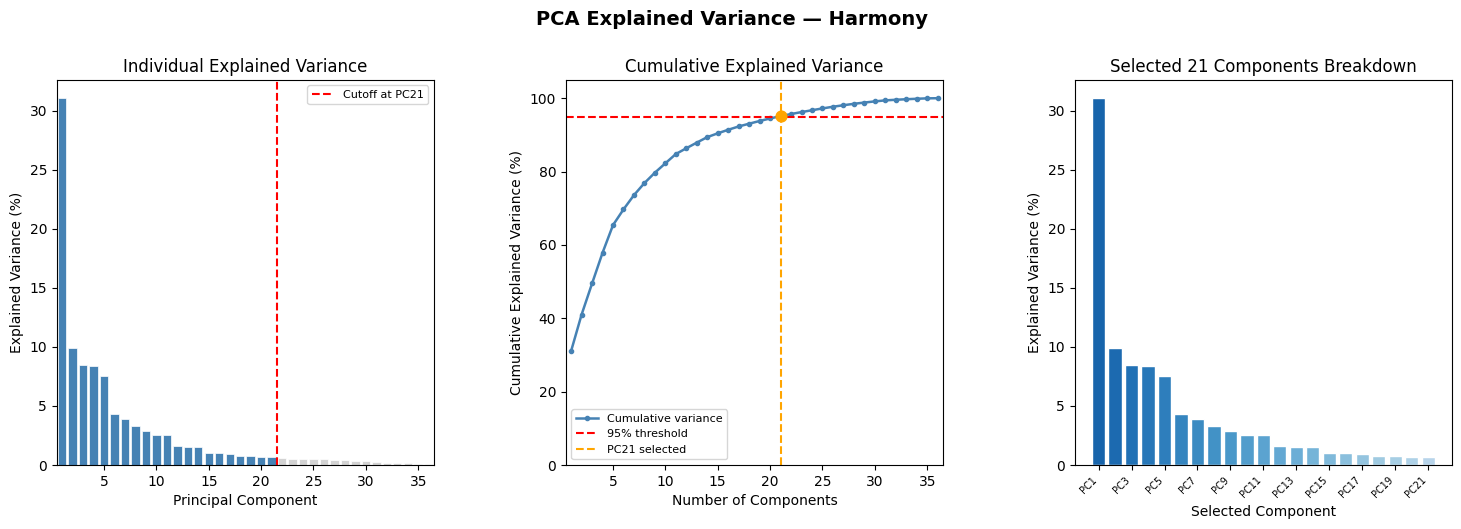

  Plot saved → C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_pca_parquets\SOUL\Harmony_pca_variance.png
  Final shape: (1000, 22)

  Preview of [Harmony.parquet] (head):
  --------------------------------------------------
                  id       PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13      PC14      PC15      PC16      PC17      PC18      PC19      PC20      PC21
0Gj4pqFby71rvq08.mp3  3.495696 -0.527790 -0.014155 -0.536419  1.893676  0.889598 -0.206815 -0.777040 -0.499341 -0.004888 -0.633527  0.059948 -0.013591 -0.134790 -0.346389 -0.304422 -1.239891  0.032192  0.038976 -0.134576 -0.201248
0aTr8HKBZUuxwexW.mp3  1.251647  2.674399  2.615957  0.681026 -1.059241  0.427174  2.001665  5.228550 -0.798902  0.117511  0.000182 -0.224533 -1.380930 -0.546863  0.285441  0.856721 -0.134640  1.329930  0.207979 -0.844620 -0.303043
0diSaWOZL45lxPZC.mp3 -5.632607  0.540746 -0.829151  0.

C:\Users\Sid\AppData\Local\Temp\ipykernel_19788\445239771.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


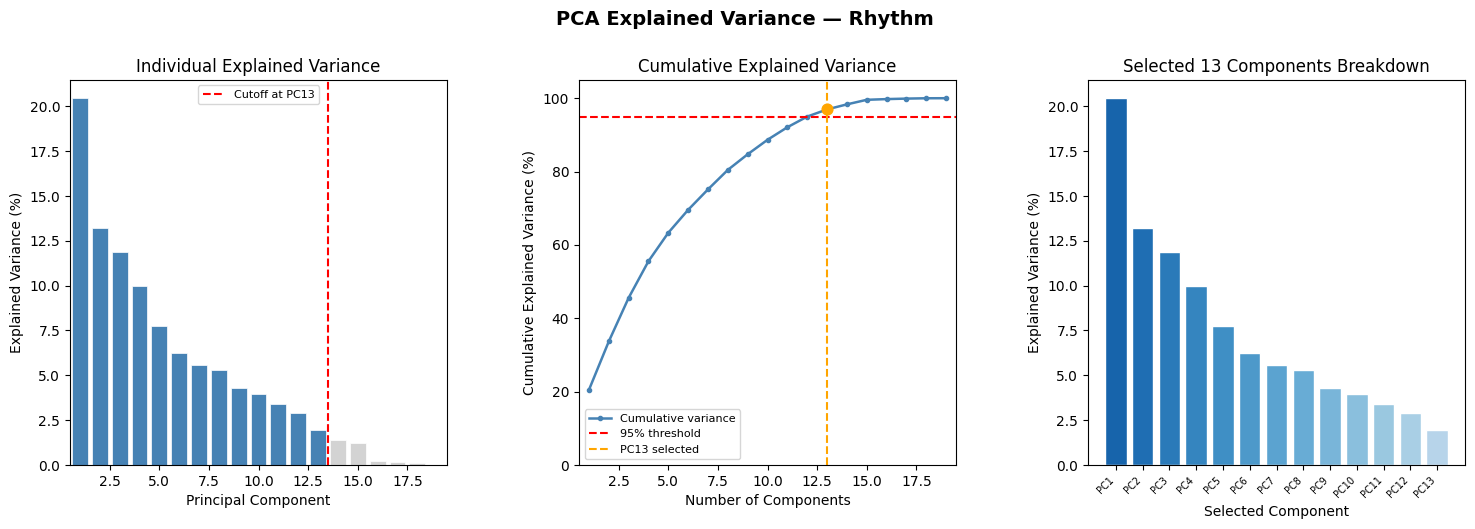

  Plot saved → C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_pca_parquets\SOUL\Rhythm_pca_variance.png
  Final shape: (1000, 14)

  Preview of [Rhythm.parquet] (head):
  --------------------------------------------------
                  id       PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13
0Gj4pqFby71rvq08.mp3  3.465866  0.670870 -0.885055 -2.598165  0.007845  1.476979 -1.922161 -1.363743 -1.594438 -0.512205  0.168068 -0.404452  0.518184
0aTr8HKBZUuxwexW.mp3 -1.526077 -1.972977  0.147714 -2.192979 -2.217993  1.311709 -1.099047 -0.407487 -0.001554  0.628595 -1.079193 -0.987194  0.198367
0diSaWOZL45lxPZC.mp3  0.262315  0.985846 -0.326847 -0.132515 -0.222205  0.669286  1.803832  0.273512 -0.795391 -0.677093 -0.632229  0.248809 -0.643448
0cQdObcXUyY1tLkj.mp3  2.425929 -2.110959  0.803002 -0.419968 -0.665800 -0.870026 -1.011210 -1.043488 -0.511497  0.269324 -0.124253  0.140965 -0.1

C:\Users\Sid\AppData\Local\Temp\ipykernel_19788\445239771.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


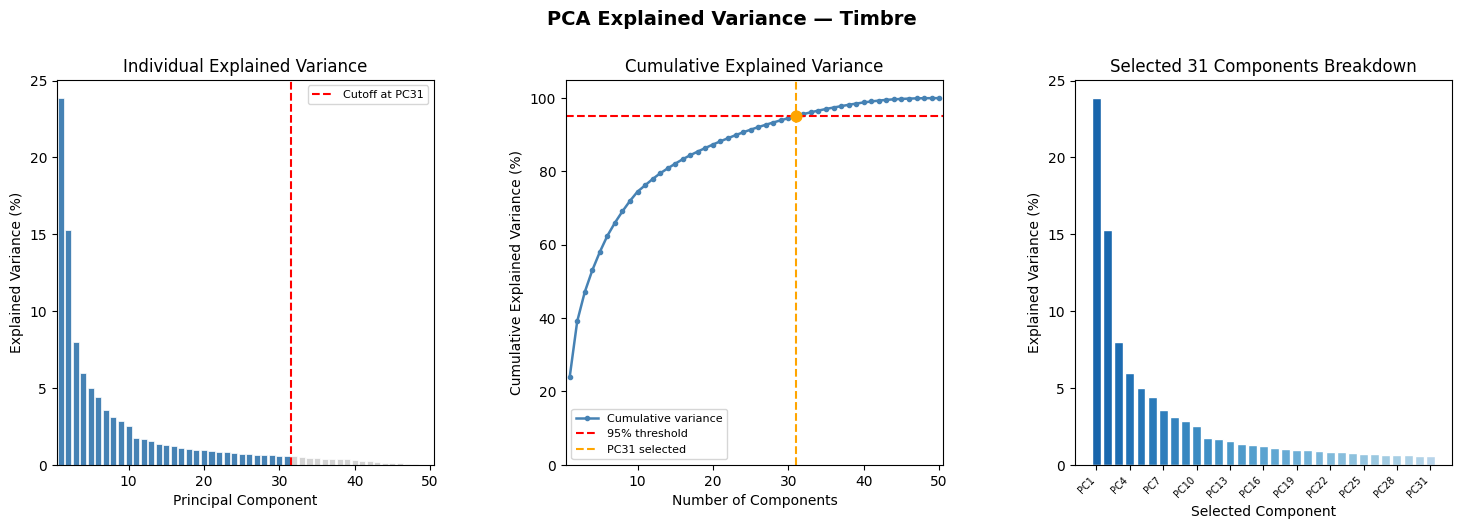

  Plot saved → C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_pca_parquets\SOUL\Timbre_pca_variance.png
  Final shape: (1000, 32)

  Preview of [Timbre.parquet] (head):
  --------------------------------------------------
                  id       PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13      PC14      PC15      PC16      PC17      PC18      PC19      PC20      PC21      PC22      PC23      PC24      PC25      PC26      PC27      PC28      PC29      PC30      PC31
0Gj4pqFby71rvq08.mp3  2.474951 -2.859982 -5.697117  2.415375  1.270676 -0.303843 -0.651134 -0.263158 -1.623839 -0.716870 -0.108934 -0.689545  0.532933  0.952277  0.164952  0.712126 -0.786144 -0.205669  0.299471  0.150039 -0.174573  0.008951  1.234541 -0.048836  0.031381 -0.151069  1.070583  0.583147 -0.570690  0.248134  0.082344
0aTr8HKBZUuxwexW.mp3  7.476791 -2.730004 -0.297447 -1.655886 -5.564024 -0.377581  0.404

In [164]:
summary = auto_pca(
    input_folder="C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_parquets\SOUL",
    output_folder="C:\SID\Apoorva\Project\Music Maven Project\genre_specific_feature_isolation_pca_parquets\SOUL",
)

<h3> Apply Kmeans clustering on all PCA-reduced parquets and auto-finds optimal k using silhouette score

In [165]:
def kmeans_clustering_single(input_folder: str,
                              output_folder: str,
                              n_clusters: int = None,
                              k_range: tuple = (2, 20),
                              random_state: int = 42,
                              save_plot: bool = False,
                              plot_output_folder: str = None) -> dict:
    """
    Applies K-Means clustering on all PCA-reduced parquets in input_folder.
    If n_clusters is None, auto-finds optimal k using silhouette score.
    Saves output parquet per file with columns: id, cluster_id_<filename>.

    Args:
        input_folder:        Path to folder containing PCA-reduced .parquet files.
        output_folder:       Path to folder to save clustered output parquets.
        n_clusters:          Number of clusters to form. If None, auto-detected (default None).
        k_range:             Range of k values to search for optimal clusters (default (2, 20)).
        random_state:        Random seed for reproducibility (default 42).
        save_plot:           Whether to save plots as PNG files (default False).
        plot_output_folder:  Folder to save plots if save_plot=True.

    Returns:
        dict: {filename: dataframe with id + cluster_id_<stem> columns}
    """

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    from pathlib import Path

    input_path  = Path(input_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    plot_path = Path(plot_output_folder) if plot_output_folder else output_path
    plot_path.mkdir(parents=True, exist_ok=True)

    parquet_files = sorted(input_path.glob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No .parquet files found in: {input_folder}")

    results = {}

    for pq_file in parquet_files:
        print(f"\n{'='*60}")
        print(f"Processing: {pq_file.name}")
        print(f"{'='*60}")

        # ─── STEP 1: LOAD ─────────────────────────────────────────
        df         = pd.read_parquet(pq_file)
        file_label = pq_file.stem                          # e.g. "Timbre"
        cluster_col = f"cluster_id_{file_label}"           # e.g. "cluster_id_Timbre"
        print(f"  Shape      : {df.shape}")
        print(f"  Output col : {cluster_col}")

        # ─── STEP 2: PREPARE FEATURES ─────────────────────────────
        X   = df.drop(columns=['id'], errors='ignore').dropna()
        ids = df.loc[X.index, 'id'] if 'id' in df.columns else pd.Series(X.index)

        # ─── STEP 3: FIND OPTIMAL K VIA SILHOUETTE SCORE ──────────
        if n_clusters is None:
            print(f"\n  🔍 Searching optimal k in range {k_range}...")
            k_min, k_max = k_range
            k_max        = min(k_max, len(X) - 1)
            k_values     = list(range(k_min, k_max + 1))
            sil_scores   = []

            for k in k_values:
                lbl = KMeans(n_clusters=k, random_state=random_state,
                             n_init=10).fit_predict(X)
                sil = silhouette_score(X, lbl, sample_size=min(5000, len(X)),
                                       random_state=random_state)
                sil_scores.append(sil)
                print(f"    k={k:>3}  →  silhouette = {sil:.4f}")

            optimal_k   = k_values[int(np.argmax(sil_scores))]
            optimal_sil = max(sil_scores)
            print(f"\n  ✅ Optimal k = {optimal_k}  (silhouette = {optimal_sil:.4f})")

            # ── Silhouette score vs K plot ─────────────────────────
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(k_values, sil_scores, marker='o', markersize=6,
                    color='steelblue', linewidth=1.8, label='Silhouette Score')
            ax.axvline(x=optimal_k, color='red', linestyle='--', linewidth=1.5,
                       label=f'Optimal k = {optimal_k}')
            ax.scatter([optimal_k], [optimal_sil], color='red', zorder=5, s=100)
            ax.annotate(f'  k={optimal_k}\n  sil={optimal_sil:.4f}',
                        xy=(optimal_k, optimal_sil), fontsize=9, color='red')
            ax.set_xlabel('Number of Clusters (k)', fontsize=12)
            ax.set_ylabel('Silhouette Score', fontsize=12)
            ax.set_title(f'Silhouette Score vs K — {file_label}',
                         fontsize=13, fontweight='bold')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            if save_plot:
                plt.savefig(plot_path / f"{file_label}_silhouette.png", dpi=150, bbox_inches='tight')
                print(f"  💾 Silhouette plot saved → {plot_path / f'{file_label}_silhouette.png'}")
            plt.show()
            plt.close()

        else:
            optimal_k = n_clusters
            print(f"  ℹ️  Using provided n_clusters = {optimal_k}")

        # ─── STEP 4: KMEANS WITH OPTIMAL K ────────────────────────
        labels = KMeans(n_clusters=optimal_k, random_state=random_state,
                        n_init=10).fit_predict(X)

        print(f"\n  ✅ Clusters    : {optimal_k}")
        print(f"  📊 Total points: {len(labels)}")
        print(f"\n  Cluster distribution:")
        print(pd.Series(labels).value_counts().sort_index().to_string())

        # ─── STEP 5: CLUSTER SCATTER PLOT ─────────────────────────
        unique_labels = sorted(set(labels))
        palette       = {l: sns.color_palette('tab10', 10)[l % 10] for l in unique_labels}

        fig, ax = plt.subplots(figsize=(12, 8))
        for label in unique_labels:
            mask = labels == label
            ax.scatter(X['PC1'].values[mask], X['PC2'].values[mask],
                       c=[palette[label]], label=f'Cluster {label}',
                       s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
        ax.set_title(f'KMeans Clustering ({optimal_k} Clusters) — {file_label}',
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('PC1', fontsize=12)
        ax.set_ylabel('PC2', fontsize=12)
        ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_plot:
            plt.savefig(plot_path / f"{file_label}_kmeans.png", dpi=150, bbox_inches='tight')
            print(f"  💾 Cluster plot saved → {plot_path / f'{file_label}_kmeans.png'}")
        plt.show()
        plt.close()

        # ─── STEP 6: BUILD OUTPUT DATAFRAME ───────────────────────
        # id as first column, cluster_id_<file_label> as second column
        df_out = pd.DataFrame({
            'id'         : ids.values,
            cluster_col  : labels
        })

        # ─── STEP 7: SAVE OUTPUT PARQUET ──────────────────────────
        out_file = output_path / pq_file.name
        df_out.to_parquet(out_file, index=False)
        print(f"\n  💾 Saved → {out_file}")
        print(f"  Columns: {list(df_out.columns)}")

        # ─── STEP 8: PREVIEW ──────────────────────────────────────
        print(f"\n  📋 Preview [{pq_file.name}]:")
        print(f"  {'-'*40}")
        print(df_out.head(10).to_string(index=False))
        print(f"  {'-'*40}")

        results[pq_file.name] = df_out

    print(f"\n{'='*60}")
    print(f"Done. {len(parquet_files)} file(s) processed → {output_folder}")
    return results


Processing: Energy_and_Dynamics.parquet
  Shape      : (1000, 4)
  Output col : cluster_id_Energy_and_Dynamics

  🔍 Searching optimal k in range (2, 20)...
    k=  2  →  silhouette = 0.4434
    k=  3  →  silhouette = 0.4562
    k=  4  →  silhouette = 0.3842
    k=  5  →  silhouette = 0.3746
    k=  6  →  silhouette = 0.3478
    k=  7  →  silhouette = 0.3616
    k=  8  →  silhouette = 0.3672
    k=  9  →  silhouette = 0.3668
    k= 10  →  silhouette = 0.3367
    k= 11  →  silhouette = 0.3363
    k= 12  →  silhouette = 0.3373
    k= 13  →  silhouette = 0.3361
    k= 14  →  silhouette = 0.3292
    k= 15  →  silhouette = 0.3351
    k= 16  →  silhouette = 0.3250
    k= 17  →  silhouette = 0.3287
    k= 18  →  silhouette = 0.3384
    k= 19  →  silhouette = 0.3393
    k= 20  →  silhouette = 0.3314

  ✅ Optimal k = 3  (silhouette = 0.4562)


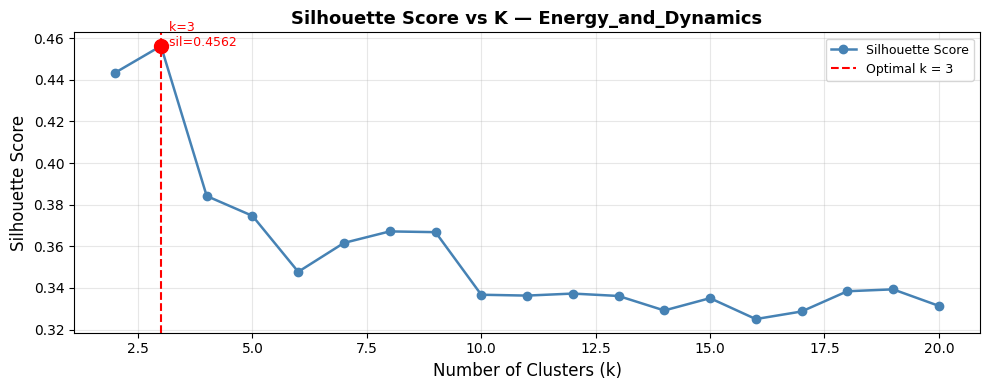


  ✅ Clusters    : 3
  📊 Total points: 1000

  Cluster distribution:
0    600
1    398
2      2


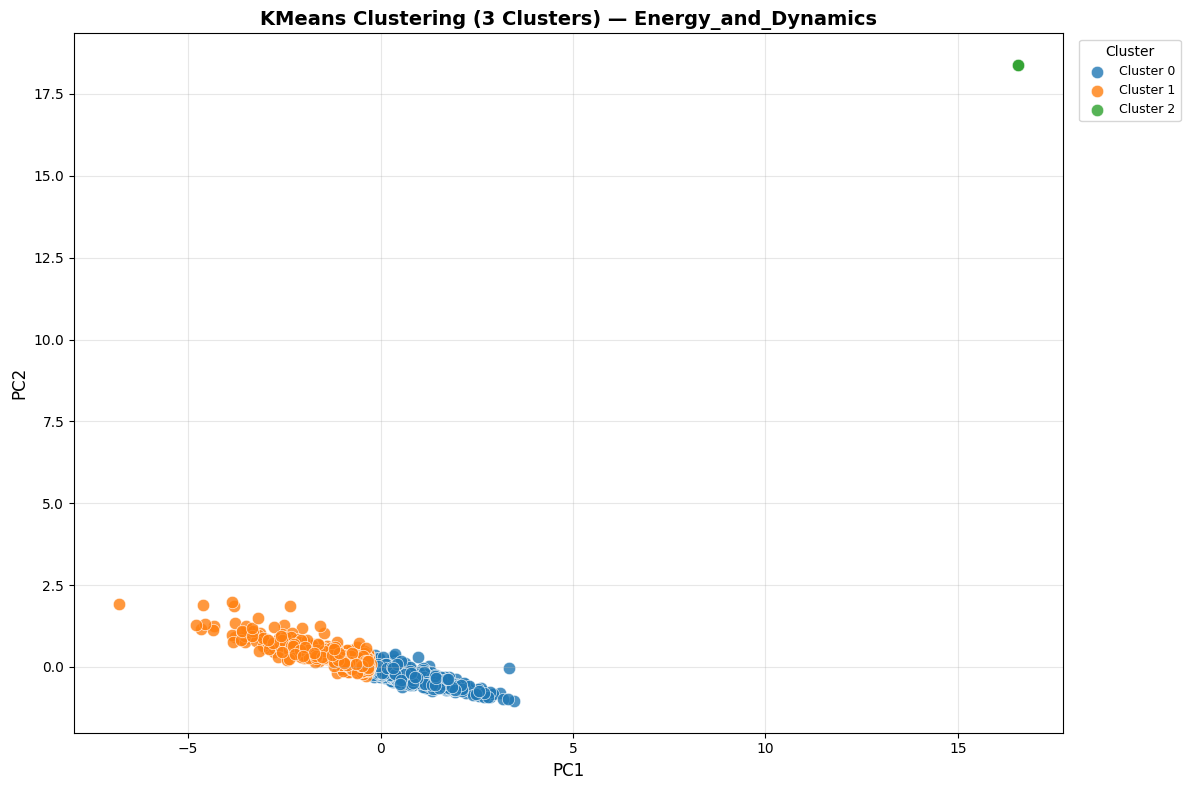


  💾 Saved → C:\SID\Apoorva\Project\Music Maven Project\Kmeans_clustered_samples\SOUL\Energy_and_Dynamics.parquet
  Columns: ['id', 'cluster_id_Energy_and_Dynamics']

  📋 Preview [Energy_and_Dynamics.parquet]:
  ----------------------------------------
                  id  cluster_id_Energy_and_Dynamics
0Gj4pqFby71rvq08.mp3                               1
0aTr8HKBZUuxwexW.mp3                               1
0diSaWOZL45lxPZC.mp3                               1
0cQdObcXUyY1tLkj.mp3                               0
09zRPbUiTrBZJoi2.mp3                               1
02io0Qj0jV8AFKAF.mp3                               1
0JtMllx4BGVKFLku.mp3                               0
0hi5FGoizAXxin1K.mp3                               1
0jP2q4c51hZRm8eK.mp3                               0
0ShtmfqyvW1hKjw7.mp3                               0
  ----------------------------------------

Processing: Harmony.parquet
  Shape      : (1000, 22)
  Output col : cluster_id_Harmony

  🔍 Searching optimal k in rang

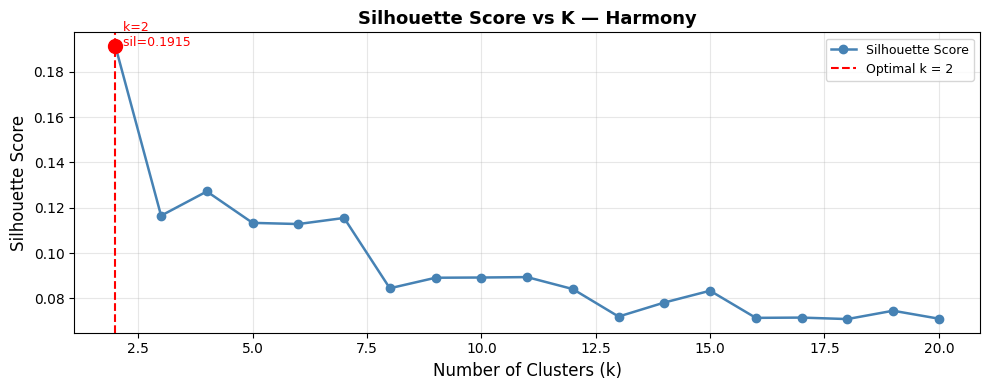


  ✅ Clusters    : 2
  📊 Total points: 1000

  Cluster distribution:
0    552
1    448


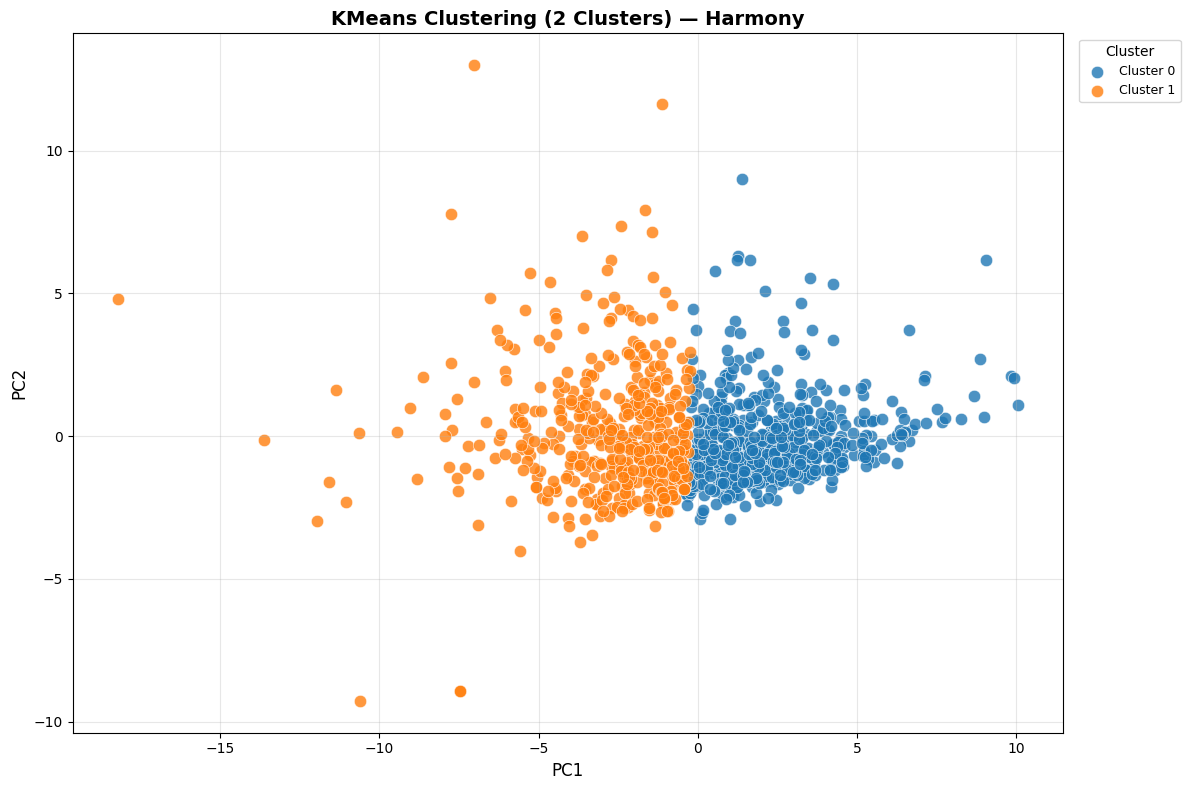


  💾 Saved → C:\SID\Apoorva\Project\Music Maven Project\Kmeans_clustered_samples\SOUL\Harmony.parquet
  Columns: ['id', 'cluster_id_Harmony']

  📋 Preview [Harmony.parquet]:
  ----------------------------------------
                  id  cluster_id_Harmony
0Gj4pqFby71rvq08.mp3                   0
0aTr8HKBZUuxwexW.mp3                   0
0diSaWOZL45lxPZC.mp3                   1
0cQdObcXUyY1tLkj.mp3                   0
09zRPbUiTrBZJoi2.mp3                   1
02io0Qj0jV8AFKAF.mp3                   1
0JtMllx4BGVKFLku.mp3                   1
0hi5FGoizAXxin1K.mp3                   0
0jP2q4c51hZRm8eK.mp3                   0
0ShtmfqyvW1hKjw7.mp3                   1
  ----------------------------------------

Processing: Rhythm.parquet
  Shape      : (1000, 14)
  Output col : cluster_id_Rhythm

  🔍 Searching optimal k in range (2, 20)...
    k=  2  →  silhouette = 0.1724
    k=  3  →  silhouette = 0.1443
    k=  4  →  silhouette = 0.1595
    k=  5  →  silhouette = 0.1577
    k=  6  →  silhoue

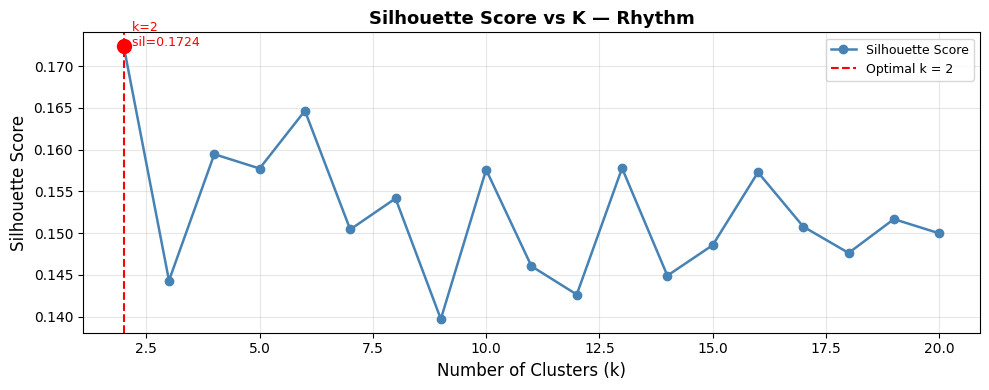


  ✅ Clusters    : 2
  📊 Total points: 1000

  Cluster distribution:
0    725
1    275


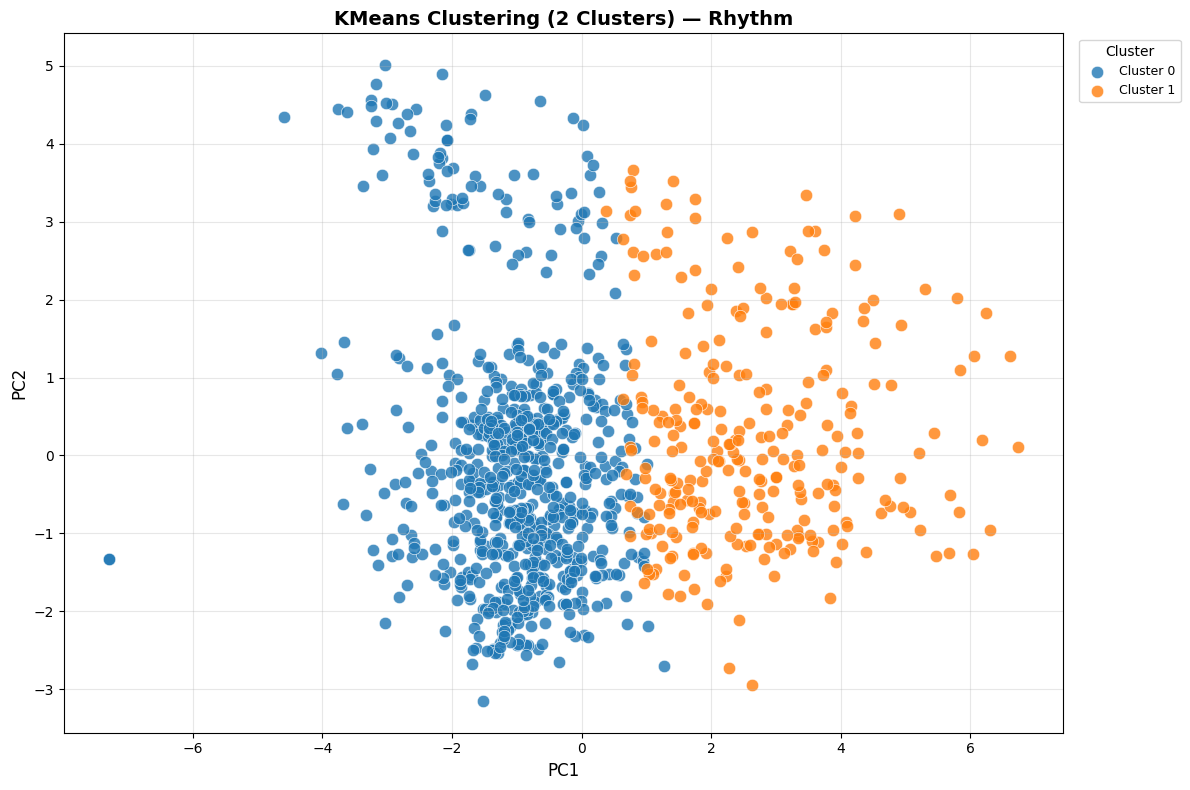


  💾 Saved → C:\SID\Apoorva\Project\Music Maven Project\Kmeans_clustered_samples\SOUL\Rhythm.parquet
  Columns: ['id', 'cluster_id_Rhythm']

  📋 Preview [Rhythm.parquet]:
  ----------------------------------------
                  id  cluster_id_Rhythm
0Gj4pqFby71rvq08.mp3                  1
0aTr8HKBZUuxwexW.mp3                  0
0diSaWOZL45lxPZC.mp3                  0
0cQdObcXUyY1tLkj.mp3                  1
09zRPbUiTrBZJoi2.mp3                  0
02io0Qj0jV8AFKAF.mp3                  0
0JtMllx4BGVKFLku.mp3                  0
0hi5FGoizAXxin1K.mp3                  1
0jP2q4c51hZRm8eK.mp3                  1
0ShtmfqyvW1hKjw7.mp3                  0
  ----------------------------------------

Processing: Timbre.parquet
  Shape      : (1000, 32)
  Output col : cluster_id_Timbre

  🔍 Searching optimal k in range (2, 20)...
    k=  2  →  silhouette = 0.1657
    k=  3  →  silhouette = 0.1182
    k=  4  →  silhouette = 0.0936
    k=  5  →  silhouette = 0.0954
    k=  6  →  silhouette = 0.0876
 

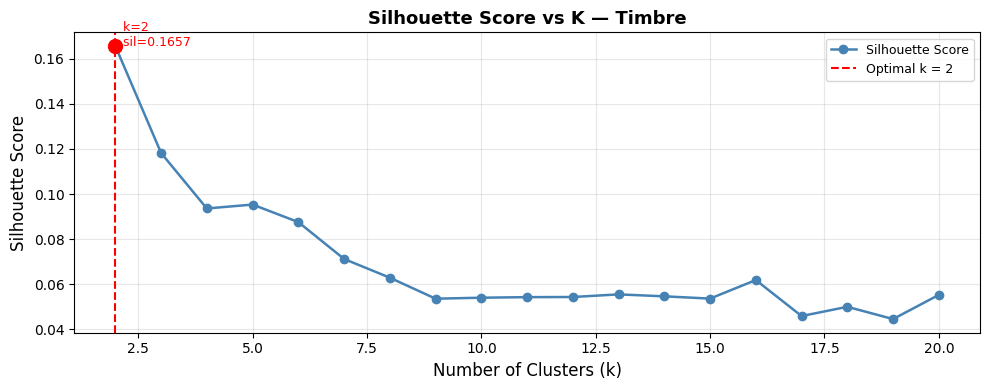


  ✅ Clusters    : 2
  📊 Total points: 1000

  Cluster distribution:
0    575
1    425


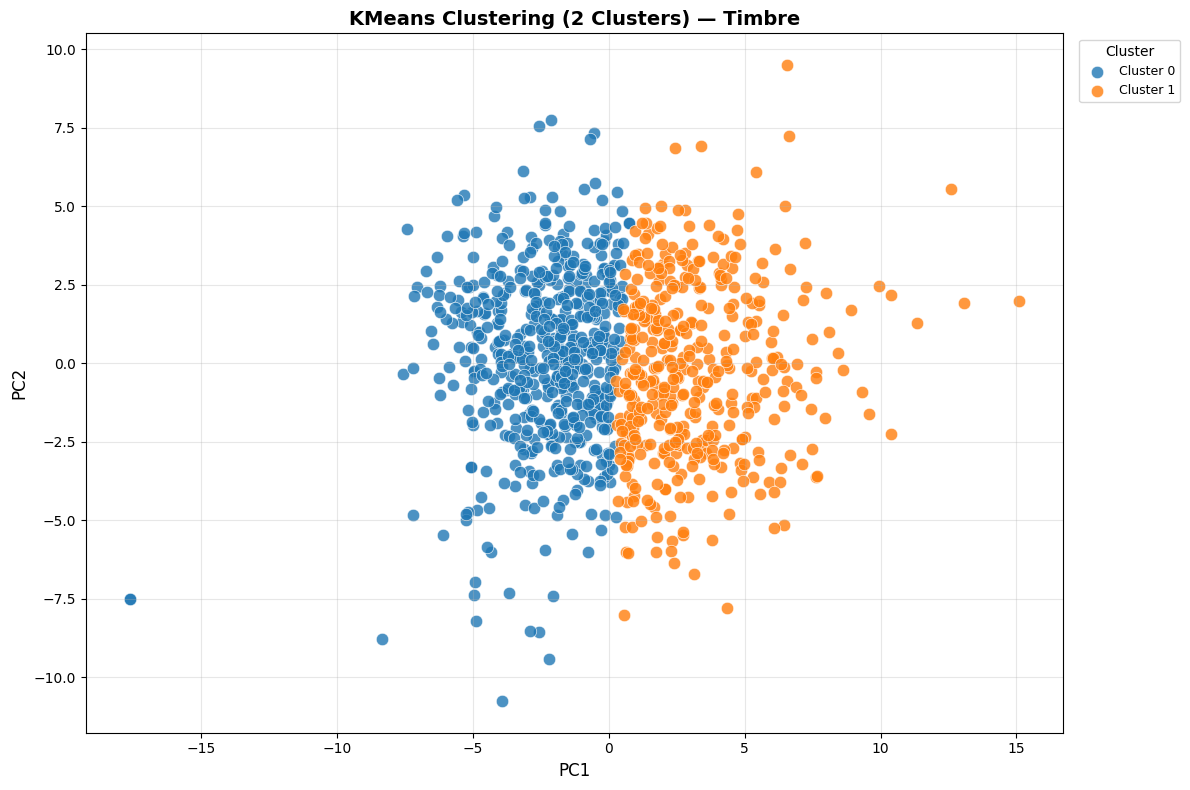


  💾 Saved → C:\SID\Apoorva\Project\Music Maven Project\Kmeans_clustered_samples\SOUL\Timbre.parquet
  Columns: ['id', 'cluster_id_Timbre']

  📋 Preview [Timbre.parquet]:
  ----------------------------------------
                  id  cluster_id_Timbre
0Gj4pqFby71rvq08.mp3                  1
0aTr8HKBZUuxwexW.mp3                  1
0diSaWOZL45lxPZC.mp3                  1
0cQdObcXUyY1tLkj.mp3                  0
09zRPbUiTrBZJoi2.mp3                  1
02io0Qj0jV8AFKAF.mp3                  1
0JtMllx4BGVKFLku.mp3                  0
0hi5FGoizAXxin1K.mp3                  1
0jP2q4c51hZRm8eK.mp3                  0
0ShtmfqyvW1hKjw7.mp3                  1
  ----------------------------------------

Done. 4 file(s) processed → C:\SID\Apoorva\Project\Music Maven Project\Kmeans_clustered_samples\SOUL


In [166]:
results = kmeans_clustering_single(
    input_folder  = "C:\\SID\\Apoorva\\Project\\Music Maven Project\\genre_specific_feature_isolation_pca_parquets\\SOUL",
    output_folder = "C:\\SID\\Apoorva\\Project\\Music Maven Project\\Kmeans_clustered_samples\\SOUL",
)

<h4> Combining the individual parquets saved after clustering above, saving in -> combined_parquet_after_kmeans_clustering

In [167]:
def combine_parquets_on_id(input_folder: str,
                            output_folder: str,
                            output_filename: str = "combined.parquet") -> pd.DataFrame:
    """
    Reads all parquets from input_folder, merges them on 'id' column,
    and saves the combined parquet to output_folder.

    Args:
        input_folder:     Path to folder containing input .parquet files.
        output_folder:    Path to folder to save the combined parquet.
        output_filename:  Name of the output parquet file (default 'combined.parquet').

    Returns:
        combined dataframe merged on id.
    """

    from pathlib import Path
    import pandas as pd

    input_path  = Path(input_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    parquet_files = sorted(input_path.glob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No .parquet files found in: {input_folder}")

    print(f"Found {len(parquet_files)} parquet file(s) to combine.")

    # ─── STEP 1: LOAD ALL PARQUETS ────────────────────────────────
    df_combined = None

    for pq_file in parquet_files:
        df = pd.read_parquet(pq_file)
        print(f"  Loaded: {pq_file.name}  →  shape: {df.shape}")

        # ─── STEP 2: MERGE ON ID ──────────────────────────────────
        if df_combined is None:
            df_combined = df
        else:
            df_combined = df_combined.merge(df, on='id', how='outer')

    print(f"\n  ✅ Combined shape : {df_combined.shape}")
    print(f"  ✅ Columns        : {list(df_combined.columns)}")

    # ─── STEP 3: SAVE ─────────────────────────────────────────────
    out_file = output_path / output_filename
    df_combined.to_parquet(out_file, index=False)
    print(f"\n  💾 Saved → {out_file}")

    # ─── STEP 4: PREVIEW ──────────────────────────────────────────
    print(f"\n  📋 Preview (head):")
    print(f"  {'-'*50}")
    print(df_combined.head(10).to_string(index=False))
    print(f"  {'-'*50}")

    return df_combined

In [168]:
df_combined = combine_parquets_on_id(
    input_folder    = "C:\\SID\\Apoorva\\Project\\Music Maven Project\\Kmeans_clustered_samples\\SOUL",
    output_folder   = "C:\\SID\\Apoorva\\Project\\Music Maven Project\\combined_parquet_after_kmeans_clustering\\SOUL",
    output_filename = "SOUL_Kmeans_clustered_combined.parquet",   # optional, default is combined.parquet
)

Found 4 parquet file(s) to combine.
  Loaded: Energy_and_Dynamics.parquet  →  shape: (1000, 2)
  Loaded: Harmony.parquet  →  shape: (1000, 2)
  Loaded: Rhythm.parquet  →  shape: (1000, 2)
  Loaded: Timbre.parquet  →  shape: (1000, 2)

  ✅ Combined shape : (1000, 5)
  ✅ Columns        : ['id', 'cluster_id_Energy_and_Dynamics', 'cluster_id_Harmony', 'cluster_id_Rhythm', 'cluster_id_Timbre']

  💾 Saved → C:\SID\Apoorva\Project\Music Maven Project\combined_parquet_after_kmeans_clustering\SOUL\SOUL_Kmeans_clustered_combined.parquet

  📋 Preview (head):
  --------------------------------------------------
                  id  cluster_id_Energy_and_Dynamics  cluster_id_Harmony  cluster_id_Rhythm  cluster_id_Timbre
02io0Qj0jV8AFKAF.mp3                               1                   1                  0                  1
09zRPbUiTrBZJoi2.mp3                               1                   1                  0                  1
0Gj4pqFby71rvq08.mp3                               1        

<h4> Create a cluster fingerprint for each song, and applies DBSCAN to cluster the fingerprints.

In [169]:
def cluster_fingerprint(input_parquet: str,
                        output_folder: str = None) -> pd.DataFrame:  # ← add parameter
    """
    Reads the combined parquet, creates a cluster fingerprint for each song,
    and applies DBSCAN to cluster the fingerprints.

    Args:
        input_parquet:   Path to the combined parquet file.
        output_folder:   Folder to save the final output parquet (optional).

    Returns:
        Dataframe with id, cluster columns, cluster_fingerprint, and DBSCAN_Cluster.
    """

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from pathlib import Path
    from sklearn.cluster import DBSCAN
    from sklearn.neighbors import NearestNeighbors

    # ─── STEP 1: LOAD ─────────────────────────────────────────────
    df = pd.read_parquet(input_parquet)
    print(f"  Loaded: {Path(input_parquet).name}  →  shape: {df.shape}")

    # ─── STEP 2: IDENTIFY CLUSTER COLUMNS ─────────────────────────
    cluster_cols = sorted([c for c in df.columns if c.startswith('cluster_id_')])
    print(f"  Cluster columns: {cluster_cols}")

    # ─── STEP 3: CREATE FINGERPRINT ───────────────────────────────
    df['cluster_fingerprint'] = df[cluster_cols].astype(str).agg('_'.join, axis=1)

    print(f"\n  ✅ Total unique fingerprints : {df['cluster_fingerprint'].nunique()}")
    print(f"  ✅ Total songs               : {len(df)}")

    print(f"\n  📋 Top 10 most common fingerprints:")
    print(f"  {'-'*50}")
    print(df['cluster_fingerprint'].value_counts().head(10).to_string())
    print(f"  {'-'*50}")

    # ─── STEP 4: DBSCAN ON CLUSTER COLUMNS ────────────────────────
    X = df[cluster_cols].values.astype(float)

    # Auto-estimate eps using k-distance elbow
    k     = 5
    nbrs  = NearestNeighbors(n_neighbors=k).fit(X)
    dists, _ = nbrs.kneighbors(X)
    k_dists  = np.sort(dists[:, -1])[::-1]

    # Elbow point
    n       = len(k_dists)
    x_norm  = np.arange(n) / (n - 1)
    y_norm  = (k_dists - k_dists.min()) / (k_dists.max() - k_dists.min() + 1e-10)
    line    = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
    line   /= np.linalg.norm(line)
    vecs    = np.column_stack([x_norm - x_norm[0], y_norm - y_norm[0]])
    cross   = np.abs(vecs[:, 0] * line[1] - vecs[:, 1] * line[0])
    eps     = max(float(k_dists[int(np.argmax(cross))]), 1e-4)

    print(f"\n  🔍 DBSCAN → auto eps = {eps:.4f}, min_samples = {k}")

    labels = DBSCAN(eps=eps, min_samples=k).fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = int(np.sum(labels == -1))

    df['DBSCAN_Cluster'] = labels

    print(f"  ✅ DBSCAN clusters : {n_clusters}")
    print(f"  ✅ Noise points    : {n_noise} ({n_noise/len(df)*100:.1f}%)")
    print(f"\n  Cluster distribution:")
    print(pd.Series(labels).value_counts().sort_index().to_string())

    # ─── STEP 5: VISUALIZE ────────────────────────────────────────
    unique_labels = sorted(set(labels))
    n_colors      = max(n_clusters, 1)
    cmap          = plt.cm.get_cmap('tab20', n_colors)
    color_map     = {lbl: ('#e74c3c' if lbl == -1 else cmap(i % n_colors))
                     for i, lbl in enumerate(unique_labels)}
    point_colors  = [color_map[lbl] for lbl in labels]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('Cluster Fingerprint — DBSCAN Analysis',
                 fontsize=14, fontweight='bold')

    # ── Plot 1: Scatter (first 2 cluster columns) ─────────────────
    ax1 = axes[0]
    ax1.scatter(X[:, 0], X[:, 1], c=point_colors, s=15, alpha=0.6, linewidths=0)
    for lbl in unique_labels[:15]:
        ax1.scatter([], [], c=[color_map[lbl]], s=30,
                    label='Noise' if lbl == -1 else f'C{lbl}')
    ax1.legend(fontsize=7, loc='upper right', ncol=2)
    ax1.set_xlabel(cluster_cols[0].replace('cluster_id_', ''))
    ax1.set_ylabel(cluster_cols[1].replace('cluster_id_', ''))
    ax1.set_title('DBSCAN Cluster Scatter')

    # ── Plot 2: k-Distance graph ──────────────────────────────────
    ax2 = axes[1]
    ax2.plot(k_dists, color='steelblue', linewidth=1.5)
    ax2.axhline(y=eps, color='red', linestyle='--', linewidth=1.5,
                label=f'eps = {eps:.4f}')
    ax2.set_xlabel('Points (sorted)')
    ax2.set_ylabel(f'{k}-NN Distance')
    ax2.set_title('k-Distance Graph\n(elbow → eps estimate)')
    ax2.legend(fontsize=9)

    # ── Plot 3: Top 15 fingerprint counts bar chart ───────────────
    ax3 = axes[2]
    top_fp     = df['cluster_fingerprint'].value_counts().head(15)
    bar_colors = sns.color_palette('Blues_r', len(top_fp))
    bars       = ax3.barh(top_fp.index[::-1], top_fp.values[::-1],
                          color=bar_colors[::-1], edgecolor='white')
    for bar, val in zip(bars, top_fp.values[::-1]):
        ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=7)
    ax3.set_xlabel('Number of Songs')
    ax3.set_title('Top 15 Most Common\nCluster Fingerprints')

    plt.tight_layout()
    plt.show()
    plt.close()

    # ─── STEP 6: PREVIEW ──────────────────────────────────────────
    print(f"\n  📋 Preview (head):")
    print(f"  {'-'*50}")
    print(df[['id', 'cluster_fingerprint', 'DBSCAN_Cluster']].head(10).to_string(index=False))
    print(f"  {'-'*50}")

    # ─── STEP 7: SAVE OUTPUT ──────────────────────────────────────
    if output_folder:
        out_path = Path(output_folder)
        out_path.mkdir(parents=True, exist_ok=True)
        out_file = out_path / "cluster_fingerprint_output.parquet"
        df.to_parquet(out_file, index=False)
        print(f"\n  💾 Saved → {out_file}")

    return df

  Loaded: SOUL_Kmeans_clustered_combined.parquet  →  shape: (1000, 5)
  Cluster columns: ['cluster_id_Energy_and_Dynamics', 'cluster_id_Harmony', 'cluster_id_Rhythm', 'cluster_id_Timbre']

  ✅ Total unique fingerprints : 17
  ✅ Total songs               : 1000

  📋 Top 10 most common fingerprints:
  --------------------------------------------------
cluster_fingerprint
0_0_0_0    254
1_1_0_1    162
0_1_0_0    109
0_0_1_0    108
1_1_1_1     56
0_1_0_1     55
1_0_0_1     50
1_0_1_1     44
0_0_0_1     37
1_1_0_0     29
  --------------------------------------------------

  🔍 DBSCAN → auto eps = 0.0001, min_samples = 5
  ✅ DBSCAN clusters : 16
  ✅ Noise points    : 2 (0.2%)

  Cluster distribution:
-1       2
 0     162
 1      44
 2     109
 3      55
 4      50
 5     108
 6     254
 7      12
 8      37
 9      27
 10     23
 11     16
 12     29
 13     56
 14      9
 15      7


C:\Users\Sid\AppData\Local\Temp\ipykernel_19788\2904246503.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap          = plt.cm.get_cmap('tab20', n_colors)


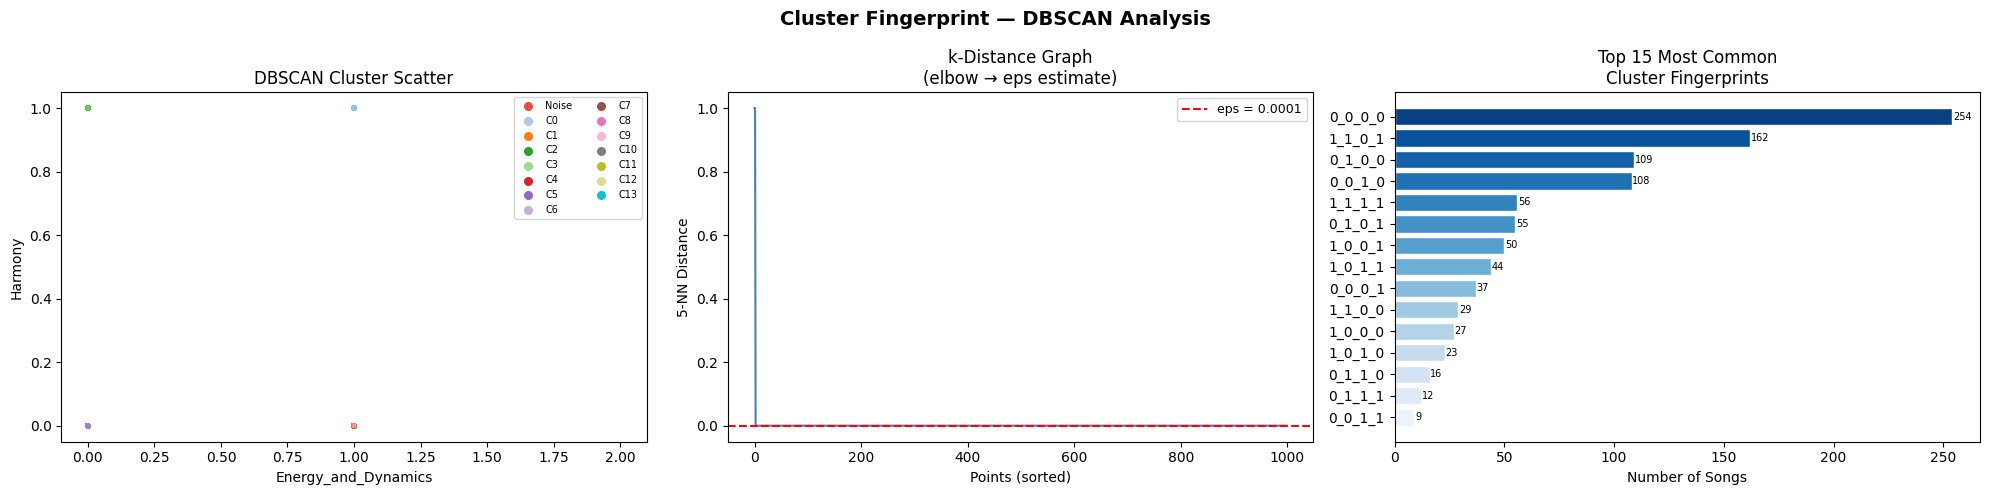


  📋 Preview (head):
  --------------------------------------------------
                  id cluster_fingerprint  DBSCAN_Cluster
02io0Qj0jV8AFKAF.mp3             1_1_0_1               0
09zRPbUiTrBZJoi2.mp3             1_1_0_1               0
0Gj4pqFby71rvq08.mp3             1_0_1_1               1
0JtMllx4BGVKFLku.mp3             0_1_0_0               2
0ShtmfqyvW1hKjw7.mp3             0_1_0_1               3
0aTr8HKBZUuxwexW.mp3             1_0_0_1               4
0cQdObcXUyY1tLkj.mp3             0_0_1_0               5
0diSaWOZL45lxPZC.mp3             1_1_0_1               0
0hi5FGoizAXxin1K.mp3             1_0_1_1               1
0jP2q4c51hZRm8eK.mp3             0_0_1_0               5
  --------------------------------------------------

  💾 Saved → C:\SID\Apoorva\Project\Music Maven Project\DBSCAN_cluster_fingerprint_result\SOUL\cluster_fingerprint_output.parquet


In [170]:
df_result = cluster_fingerprint(
    input_parquet = r"C:\\SID\\Apoorva\\Project\\Music Maven Project\\combined_parquet_after_kmeans_clustering\\SOUL\\SOUL_Kmeans_clustered_combined.parquet",
    output_folder = r"C:\SID\Apoorva\Project\Music Maven Project\DBSCAN_cluster_fingerprint_result\SOUL"
)

<h3> Saving the cluster fingerprint results into csv file -> ELECTRONIC_cluster_fingerprint_dbscan_results

In [171]:
df_result.to_csv("SOUL_cluster_fingerprint_dbscan_results.csv", index=False)

<h3> Viewing the cluster_fingerprint_output.parquet file

In [172]:
df = pd.read_parquet(r"C:\SID\Apoorva\Project\Music Maven Project\DBSCAN_cluster_fingerprint_result\SOUL\cluster_fingerprint_output.parquet").head()
df.head()

,id,cluster_id_Energy_and_Dynamics,cluster_id_Harmony,cluster_id_Rhythm,cluster_id_Timbre,cluster_fingerprint,DBSCAN_Cluster
0,02io0Qj0jV8AFKAF.mp3,1,1,0,1,1_1_0_1,0
1,09zRPbUiTrBZJoi2.mp3,1,1,0,1,1_1_0_1,0
2,0Gj4pqFby71rvq08.mp3,1,0,1,1,1_0_1_1,1
3,0JtMllx4BGVKFLku.mp3,0,1,0,0,0_1_0_0,2
4,0ShtmfqyvW1hKjw7.mp3,0,1,0,1,0_1_0_1,3


<h3> Finds similar songs to a given song_id based on cluster assignments

In [173]:
def find_similar_songs(input_parquet: str,
                       song_id: str,
                       output_folder: str,
                       top_n: int = 10) -> pd.DataFrame:
    """
    Finds similar songs to a given song_id based on cluster assignments
    and saves the results to an output parquet file.

    Args:
        input_parquet:   Path to the combined parquet file.
        song_id:         Song id to find similar songs for e.g. '08QtcDK0rtDFogFP.mp3'
        output_folder:   Path to folder to save the results parquet.
        top_n:           Number of similar songs to return (default 10).

    Returns:
        Dataframe with top_n similar songs and their similarity scores.
    """

    import pandas as pd
    from pathlib import Path

    # ─── STEP 1: LOAD ─────────────────────────────────────────────
    df = pd.read_parquet(input_parquet)

    # ─── STEP 2: CHECK SONG EXISTS ────────────────────────────────
    if song_id not in df['id'].values:
        raise ValueError(f"Song '{song_id}' not found in the parquet file.")

    # ─── STEP 3: IDENTIFY CLUSTER COLUMNS ─────────────────────────
    cluster_cols = sorted([c for c in df.columns if c.startswith('cluster_id_')])

    # ─── STEP 4: GET QUERY SONG CLUSTER VALUES ────────────────────
    song_clusters = df[df['id'] == song_id][cluster_cols].values[0]

    print(f"\n  🎵 Query song    : {song_id}")
    print(f"  📋 Cluster profile:")
    for col, val in zip(cluster_cols, song_clusters):
        print(f"     {col.replace('cluster_id_', ''):<30} → {int(val)}")

    # ─── STEP 5: COMPUTE SIMILARITY SCORE ─────────────────────────
    df['similarity_score'] = (df[cluster_cols] == song_clusters).sum(axis=1)

    # ─── STEP 6: EXCLUDE THE QUERY SONG ITSELF ────────────────────
    df_similar = (df[df['id'] != song_id]
                  .sort_values('similarity_score', ascending=False)
                  .head(top_n)[['id', 'cluster_fingerprint', 'similarity_score'] + cluster_cols]
                  .reset_index(drop=True))

    # ─── STEP 7: PRINT RESULTS ────────────────────────────────────
    print(f"\n  🔍 Top {top_n} similar songs:")
    print(f"  {'-'*60}")
    print(df_similar[['id', 'similarity_score', 'cluster_fingerprint']].to_string(index=False))
    print(f"  {'-'*60}")

    print(f"\n  📊 Similarity score breakdown:")
    score_counts = df_similar['similarity_score'].value_counts().sort_index(ascending=False)
    for score, count in score_counts.items():
        label = "exact match" if score == len(cluster_cols) else f"{score}/{len(cluster_cols)} match"
        print(f"     Score {score} ({label}) → {count} song(s)")

    # ─── STEP 8: SAVE OUTPUT ──────────────────────────────────────
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    # Clean song_id for use in filename e.g. "08QtcDK0rtDFogFP.mp3" → "08QtcDK0rtDFogFP"
    clean_song_id = Path(song_id).stem
    out_file      = output_path / f"similar_songs_{clean_song_id}.parquet"

    df_similar.to_parquet(out_file, index=False)
    print(f"\n  💾 Saved → {out_file}")

    return df_similar

In [174]:
df_similar = find_similar_songs(
    input_parquet = r"C:\SID\Apoorva\Project\Music Maven Project\DBSCAN_cluster_fingerprint_result\SOUL\cluster_fingerprint_output.parquet",
    song_id       = "0Gj4pqFby71rvq08.mp3",
    output_folder = r"C:\SID\Apoorva\Project\Music Maven Project\Song_similarity_files\SOUL",
    top_n         = 70
)


  🎵 Query song    : 0Gj4pqFby71rvq08.mp3
  📋 Cluster profile:
     Energy_and_Dynamics            → 1
     Harmony                        → 0
     Rhythm                         → 1
     Timbre                         → 1

  🔍 Top 70 similar songs:
  ------------------------------------------------------------
                  id  similarity_score cluster_fingerprint
yAVqGuz3Sz2FLh7s.mp3                 4             1_0_1_1
rSnVz3U3qImLWQPV.mp3                 4             1_0_1_1
2hUNruuxnKGrUtAP.mp3                 4             1_0_1_1
uCKG2cQLppg709SL.mp3                 4             1_0_1_1
yXqaVIapj8Aft3uX.mp3                 4             1_0_1_1
X1skTNKZ8HuwEDwC.mp3                 4             1_0_1_1
X1RmnNQYGnQ9lrLm.mp3                 4             1_0_1_1
SkR4grgAOvbX5bJ3.mp3                 4             1_0_1_1
OjBTZAzKfEcZPWkP.mp3                 4             1_0_1_1
SHxKXEiz7ALK7L91.mp3                 4             1_0_1_1
SlENmOECdiuYHGlz.mp3                 4

<h3> Viewing the parquet file

In [175]:
df = pd.read_parquet(r"C:\SID\Apoorva\Project\Music Maven Project\Song_similarity_files\SOUL\similar_songs_0Gj4pqFby71rvq08.parquet")
df.head(20)

,id,cluster_fingerprint,similarity_score,cluster_id_Energy_and_Dynamics,cluster_id_Harmony,cluster_id_Rhythm,cluster_id_Timbre
0,yAVqGuz3Sz2FLh7s.mp3,1_0_1_1,4,1,0,1,1
1,rSnVz3U3qImLWQPV.mp3,1_0_1_1,4,1,0,1,1
2,2hUNruuxnKGrUtAP.mp3,1_0_1_1,4,1,0,1,1
3,uCKG2cQLppg709SL.mp3,1_0_1_1,4,1,0,1,1
4,yXqaVIapj8Aft3uX.mp3,1_0_1_1,4,1,0,1,1
5,X1skTNKZ8HuwEDwC.mp3,1_0_1_1,4,1,0,1,1
6,X1RmnNQYGnQ9lrLm.mp3,1_0_1_1,4,1,0,1,1
7,SkR4grgAOvbX5bJ3.mp3,1_0_1_1,4,1,0,1,1
8,OjBTZAzKfEcZPWkP.mp3,1_0_1_1,4,1,0,1,1
9,SHxKXEiz7ALK7L91.mp3,1_0_1_1,4,1,0,1,1
